In [7]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, Lipinski, MolSurf

# إضافة مسار المشروع
sys.path.append('..')
from src.features.molecular_descriptors import generate_features, generate_features_df

# إعدادات الرسم
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


In [13]:
import pandas as pd
import os

# مسار الملف
DATA_PATH = r"C:\Users\DELL\OneDrive\Bureau\Projet_ML_master\molecular-property-prediction\data\raw\delaney.csv"

# التحقق من وجود الملف
if not os.path.exists(DATA_PATH):
    print(f"❌ File not found: {DATA_PATH}")
else:
    print("✅ File found")

    # عرض أول 10 أسطر لمعرفة التنسيق
    print("\n===== First 10 lines =====")
    with open(DATA_PATH, "r", encoding="utf-8", errors="ignore") as f:
        for i in range(10):
            line = f.readline()
            if not line:
                break
            print(line.strip())

    print("\n===== Loading dataset =====")

    try:
        # استعمال Python engine وتجاوز الأسطر المعطوبة
        df = pd.read_csv(
            DATA_PATH,
            engine="python",
            on_bad_lines="skip"
        )

        print(f"✅ Dataset loaded successfully")
        print(f"Shape: {df.shape}")

        print("\nColumns:")
        print(df.columns.tolist())

        print("\nFirst 5 rows:")
        print(df.head())

    except Exception as e:
        print(f"❌ Error: {e}")

✅ File found

===== First 10 lines =====
Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
Amigdalin,-0.9740000000000001,1,457.4320000000001,7,3,7,202.31999999999996,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O
Fenfuram,-2.885,1,201.22500000000002,1,2,2,42.24,-3.3,Cc1occc1C(=O)Nc2ccccc2
citral,-2.5789999999999997,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
Picene,-6.617999999999999,2,278.354,0,5,0,0.0,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
Thiophene,-2.2319999999999998,2,84.14299999999999,0,1,0,0.0,-1.33,c1ccsc1
benzothiazole,-2.733,2,135.191,0,2,0,12.89,-1.5,c2ccc1scnc1c2
2,2,4,6,6'-PCB,-6.545,1,326.437,0,2,1,0.0,-7.32,Clc1cc(Cl)c(c(Cl)c1)c2c(Cl)cccc2Cl
Estradiol,-4.138,1,272.388,2,4,0,40.46,-5.03,CC12CCC3C(CCc4cc(O)ccc34)C2CCC1O
Dieldrin,-4.533,1,380.913,0,5,0,12.53,-6.29,ClC4=C(Cl)C5(Cl)C

In [14]:
df.head()

,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 966 entries, 0 to 965
Data columns (total 10 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Compound ID                                      966 non-null    object 
 1   ESOL predicted log solubility in mols per litre  966 non-null    float64
 2   Minimum Degree                                   966 non-null    int64  
 3   Molecular Weight                                 966 non-null    float64
 4   Number of H-Bond Donors                          966 non-null    int64  
 5   Number of Rings                                  966 non-null    int64  
 6   Number of Rotatable Bonds                        966 non-null    int64  
 7   Polar Surface Area                               966 non-null    float64
 8   measured log solubility in mols per litre        966 non-null    float64
 9   smiles                          

In [16]:
df.describe()

,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre
count,966.000000,966.000000,966.000000,966.000000,966.000000,966.000000,966.000000,966.000000
mean,-2.861542,1.065217,204.939543,0.762940,1.425466,2.388199,38.188147,-2.937378
std,1.596109,0.251197,101.614216,1.121949,1.345163,2.750681,34.899554,1.992804
min,-9.702000,0.000000,16.043000,0.000000,0.000000,0.000000,0.000000,-9.332000
25%,-3.866000,1.000000,123.112000,0.000000,0.000000,0.000000,12.030000,-4.190000
50%,-2.763500,1.000000,184.745000,0.000000,1.000000,2.000000,29.540000,-2.780000
75%,-1.754250,1.000000,274.240500,1.000000,2.000000,4.000000,58.200000,-1.552500
max,1.091000,2.000000,764.950000,11.000000,8.000000,23.000000,268.680000,1.580000


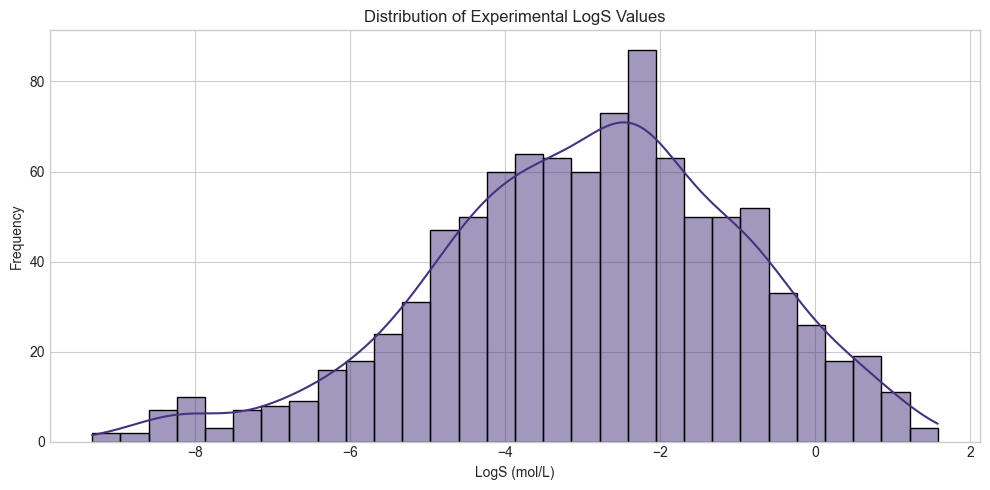

Mean LogS: -2.937
Std  LogS: 1.993
Min  LogS: -9.332
Max  LogS: 1.580


In [17]:
# توزيع قيم الذوبانية (logS)
target_col = 'measured log solubility in mols per litre'

plt.figure(figsize=(10, 5))
sns.histplot(df[target_col], kde=True, bins=30)
plt.title('Distribution of Experimental LogS Values')
plt.xlabel('LogS (mol/L)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f'Mean LogS: {df[target_col].mean():.3f}')
print(f'Std  LogS: {df[target_col].std():.3f}')
print(f'Min  LogS: {df[target_col].min():.3f}')
print(f'Max  LogS: {df[target_col].max():.3f}')

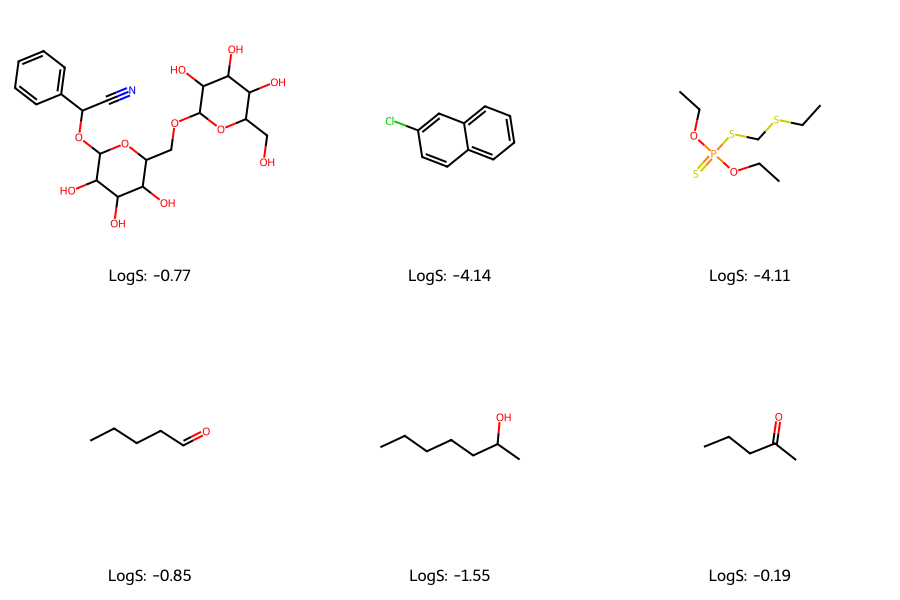

In [18]:
# اختيار 6 جزيئات كعينة
sample_indices = [0, 10, 20, 30, 40, 50]
sample_smiles = df.iloc[sample_indices]['smiles'].tolist()
sample_logS   = df.iloc[sample_indices][target_col].tolist()

# تحويل SMILES إلى جزيئات RDKit
sample_mols = [Chem.MolFromSmiles(s) for s in sample_smiles]
sample_mols = [m for m in sample_mols if m is not None]  # إزالة القيم الخاطئة

sample_labels = [f'LogS: {v:.2f}' for v in sample_logS[:len(sample_mols)]]

# رسم الجزيئات
img = Draw.MolsToGridImage(
    sample_mols,
    molsPerRow=3,
    subImgSize=(300, 300),
    legends=sample_labels
)
display(img)

In [19]:
# توليد المميزات لكل الجزيئات
print('⏳ Generating molecular descriptors...')
smiles_list = df['smiles'].tolist()
features_df = generate_features_df(smiles_list)

# إضافة القيم التجريبية للذوبانية
features_df['logS_exp'] = df[target_col].values[:len(features_df)]

print(f'✅ Features generated — Shape: {features_df.shape}')
features_df.head()

⏳ Generating molecular descriptors...
✅ Features generated — Shape: (966, 13)


,MW,LogP,TPSA,NumRotatableBonds,NumHDonors,NumHAcceptors,NumRings,NumAromaticRings,BertzCT,HallKierAlpha,LabuteASA,SMILES,logS_exp
0,457.432,-3.10802,202.32,7,7,12,3,1,759.662938,-1.73,182.935327,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77
1,201.225,2.84032,42.24,2,1,2,2,2,459.484175,-2.03,87.724095,Cc1occc1C(=O)Nc2ccccc2,-3.30
2,152.237,2.87800,17.07,4,0,1,0,0,171.311799,-0.85,68.806046,CC(C)=CCCC(C)=CC(=O),-2.06
3,278.354,6.29940,0.00,0,0,0,5,5,1071.547817,-2.86,128.158061,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87
4,84.143,1.74810,0.00,0,0,1,1,1,60.124818,-0.30,35.071766,c1ccsc1,-1.33


In [20]:
# فحص القيم المفقودة
missing = features_df.isnull().sum()
missing_cols = missing[missing > 0]

if len(missing_cols) == 0:
    print('✅ No missing values!')
else:
    print('⚠️ Missing values found:')
    print(missing_cols)

✅ No missing values!


In [21]:
# حساب الارتباط مع logS_exp
correlations = features_df.drop('SMILES', axis=1).corr()['logS_exp'].sort_values(ascending=False)

print('📈 Top positively correlated features:')
print(correlations.head(6))
print('\n📉 Top negatively correlated features:')
print(correlations.tail(6))

📈 Top positively correlated features:
logS_exp             1.000000
HallKierAlpha        0.262018
NumHDonors           0.184909
TPSA                 0.067577
NumHAcceptors       -0.021320
NumRotatableBonds   -0.312165
Name: logS_exp, dtype: float64

📉 Top negatively correlated features:
NumAromaticRings   -0.458296
NumRings           -0.540320
BertzCT            -0.605365
MW                 -0.635453
LabuteASA          -0.668069
LogP               -0.804056
Name: logS_exp, dtype: float64


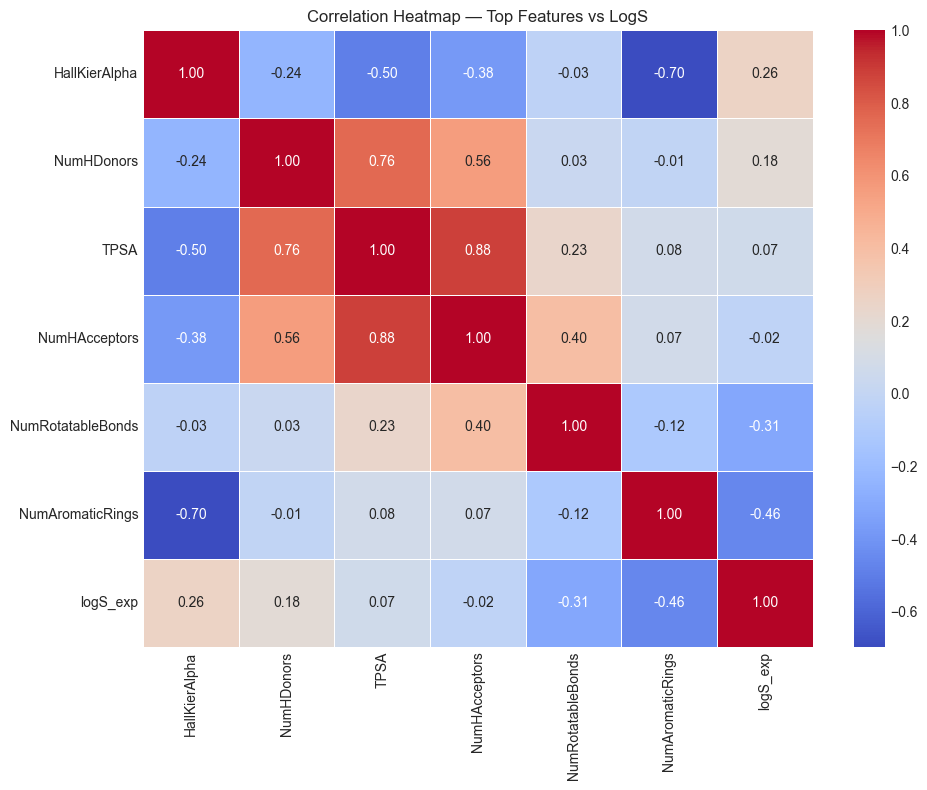

In [22]:
# Heatmap للمميزات الأكثر ارتباطاً
top_features = correlations.index[1:7].tolist()  # أفضل 6 (نستثني logS_exp نفسها)
top_features.append('logS_exp')

plt.figure(figsize=(10, 8))
sns.heatmap(
    features_df[top_features].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', linewidths=0.5
)
plt.title('Correlation Heatmap — Top Features vs LogS')
plt.tight_layout()
plt.show()

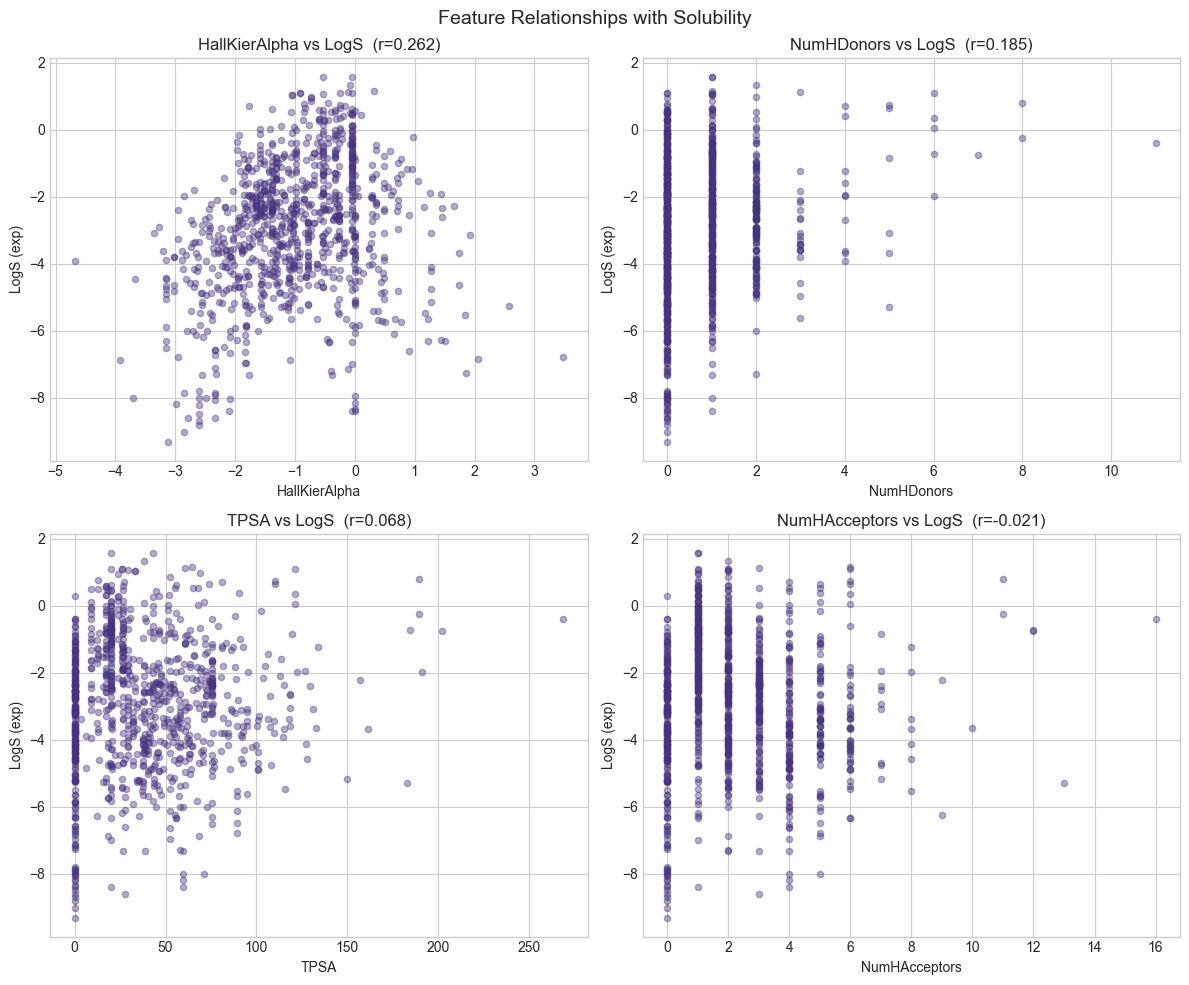

In [23]:
# Scatter plots للمميزات الأكثر تأثيراً
top_4 = correlations.index[1:5].tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, feat in enumerate(top_4):
    axes[i].scatter(features_df[feat], features_df['logS_exp'], alpha=0.4, s=20)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('LogS (exp)')
    axes[i].set_title(f'{feat} vs LogS  (r={correlations[feat]:.3f})')

plt.suptitle('Feature Relationships with Solubility', fontsize=14)
plt.tight_layout()
plt.show()